# Datathon - Case Passos Mágicos
## Modelo Preditivo de Risco de Defasagem

Este notebook desenvolve um modelo preditivo para identificar alunos em risco de defasagem, demonstrando:
1. **Feature Engineering** - Criação e seleção de variáveis
2. **Separação Treino/Teste** - Estratificada para manter proporções
3. **Modelagem Preditiva** - Random Forest, XGBoost e Logistic Regression
4. **Avaliação dos Resultados** - Métricas, curvas ROC e importância de features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost não disponível, usando GradientBoosting como alternativa")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


## 1. Carregamento e Preparação dos Dados

In [2]:
# Carregar dados - tentar CSV consolidado primeiro, senão carregar do XLSX
csv_path = '../data_consolidado.csv'
xlsx_path = '../BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Dados carregados do CSV consolidado: {df.shape}")
else:
    print("CSV consolidado não encontrado. Carregando do XLSX...")
    dfs = []
    for sheet, ano in [('PEDE2022', 2022), ('PEDE2023', 2023), ('PEDE2024', 2024)]:
        temp = pd.read_excel(xlsx_path, sheet_name=sheet)
        temp['Ano'] = ano
        dfs.append(temp)
    df = pd.concat(dfs, ignore_index=True)
    print(f"Dados carregados do XLSX: {df.shape}")

print(f"\nColunas: {list(df.columns)}")
print(f"Shape: {df.shape}")

Dados carregados do CSV consolidado: (3030, 17)

Colunas: ['Ano', 'INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Pedra', 'Defasagem', 'Fase', 'Genero', 'Idade', 'Ano_Ingresso', 'Aluno_ID', 'Ponto_Virada']
Shape: (3030, 17)


## 2. Feature Engineering

### 2.1 Definição da Variável Alvo (Target)

Um aluno é considerado **em risco de defasagem** quando:
- IAN ≤ 5.0 (defasagem moderada ou severa), OU
- Defasagem < 0, OU
- Pedra = "Quartzo" (classificação mais baixa)

Distribuição da variável alvo:
em_risco
1    1733
0    1297
Name: count, dtype: int64

Proporção de alunos em risco: 57.2%


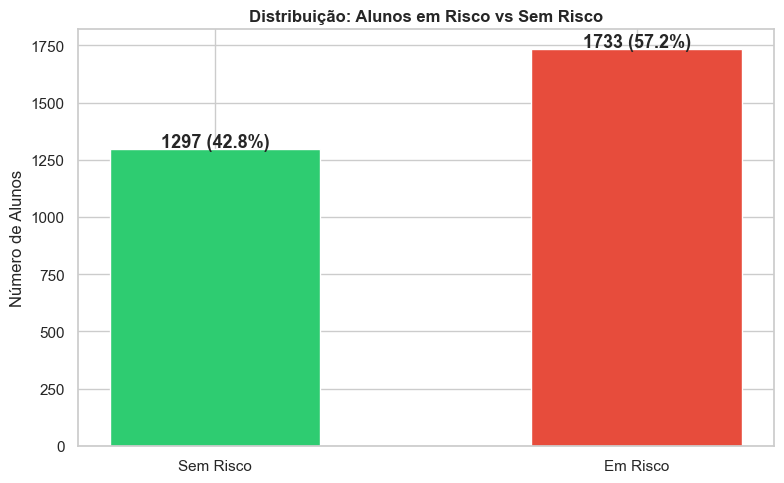

In [3]:
# Criar variável alvo: risco de defasagem
def criar_target(row):
    """Define se o aluno está em risco de defasagem."""
    em_risco = False

    # Critério 1: IAN baixo (defasagem)
    if pd.notna(row.get('IAN')) and row['IAN'] <= 5.0:
        em_risco = True

    # Critério 2: Defasagem negativa
    if pd.notna(row.get('Defasagem')) and row.get('Defasagem', 0) < 0:
        em_risco = True

    # Critério 3: Pedra Quartzo
    if pd.notna(row.get('Pedra')) and str(row.get('Pedra', '')).strip() in ['Quartzo', 'QUARTZO']:
        em_risco = True

    return 1 if em_risco else 0

df['em_risco'] = df.apply(criar_target, axis=1)

print("Distribuição da variável alvo:")
print(df['em_risco'].value_counts())
print(f"\nProporção de alunos em risco: {df['em_risco'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#2ecc71', '#e74c3c']
labels = ['Sem Risco', 'Em Risco']
counts = df['em_risco'].value_counts().sort_index()
bars = ax.bar(labels, counts.values, color=cores, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=13)
ax.set_title('Distribuição: Alunos em Risco vs Sem Risco', fontweight='bold')
ax.set_ylabel('Número de Alunos')
plt.tight_layout()
plt.savefig('../outputs/24_distribuicao_risco.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Seleção e Criação de Features

In [4]:
# Selecionar features para o modelo
feature_cols = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']

# Verificar disponibilidade
available_features = []
for col in feature_cols:
    if col in df.columns and df[col].notna().sum() > 100:
        available_features.append(col)
        print(f"  {col}: {df[col].notna().sum()} valores válidos")
    else:
        print(f"  {col}: INDISPONÍVEL ou poucos dados")

# Features adicionais
# Fase (numérica)
if 'Fase' in df.columns:
    df['Fase_num'] = pd.to_numeric(df['Fase'], errors='coerce')
    if df['Fase_num'].notna().sum() > 100:
        available_features.append('Fase_num')

# Idade
if 'Idade' in df.columns:
    df['Idade_num'] = pd.to_numeric(df['Idade'], errors='coerce')
    if df['Idade_num'].notna().sum() > 100:
        available_features.append('Idade_num')

# Anos na PM
if 'Ano_Ingresso' in df.columns and 'Ano' in df.columns:
    df['Anos_PM'] = df['Ano'] - pd.to_numeric(df['Ano_Ingresso'], errors='coerce')
    df['Anos_PM'] = df['Anos_PM'].clip(lower=0)
    if df['Anos_PM'].notna().sum() > 100:
        available_features.append('Anos_PM')

# Features derivadas (interações)
if 'IDA' in available_features and 'IEG' in available_features:
    df['IDA_x_IEG'] = df['IDA'] * df['IEG']
    available_features.append('IDA_x_IEG')

if 'IPS' in available_features and 'IAA' in available_features:
    df['IPS_x_IAA'] = df['IPS'] * df['IAA']
    available_features.append('IPS_x_IAA')

# Média dos indicadores acadêmicos
acad_cols = [c for c in ['IDA', 'IEG', 'IAA'] if c in df.columns]
if len(acad_cols) >= 2:
    df['Media_Academica'] = df[acad_cols].mean(axis=1)
    available_features.append('Media_Academica')

# Média dos indicadores psicossociais
psico_cols = [c for c in ['IPS', 'IPP'] if c in df.columns]
if len(psico_cols) >= 1:
    df['Media_Psico'] = df[psico_cols].mean(axis=1)
    available_features.append('Media_Psico')

print(f"\nFeatures selecionadas ({len(available_features)}): {available_features}")

  IDA: 2631 valores válidos
  IEG: 2954 valores válidos
  IAA: 2865 valores válidos
  IPS: 2859 valores válidos
  IPP: 3030 valores válidos
  IPV: 2852 valores válidos
  INDE: 2845 valores válidos

Features selecionadas (14): ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'Fase_num', 'Idade_num', 'Anos_PM', 'IDA_x_IEG', 'IPS_x_IAA', 'Media_Academica', 'Media_Psico']


In [5]:
# Preparar dataset final para modelagem
df_model = df[available_features + ['em_risco']].dropna()
print(f"Dataset para modelagem: {df_model.shape}")
print(f"Distribuição do target:\n{df_model['em_risco'].value_counts()}")
print(f"\nEstatísticas das features:")
df_model[available_features].describe().round(2)

Dataset para modelagem: (1620, 15)
Distribuição do target:
em_risco
1    1091
0     529
Name: count, dtype: int64

Estatísticas das features:


,IDA,IEG,IAA,IPS,IPP,IPV,INDE,Fase_num,Idade_num,Anos_PM,IDA_x_IEG,IPS_x_IAA,Media_Academica,Media_Psico
count,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00,1620.00
mean,11.59,8.25,7.92,6.21,7.43,7.54,7.21,1.83,11.59,1.36,94.45,49.88,9.25,6.82
std,2.82,1.49,2.68,1.81,0.80,1.08,0.98,1.80,2.82,1.72,25.48,22.77,1.22,0.99
min,7.00,0.00,0.00,2.50,2.50,2.50,3.03,0.00,7.00,0.00,0.00,0.00,4.33,3.14
25%,9.00,7.50,7.90,5.00,7.02,7.00,6.64,0.00,9.00,0.00,76.75,35.82,8.70,6.25
50%,11.00,8.66,8.80,7.50,7.50,7.56,7.34,1.00,11.00,1.00,91.30,56.43,9.33,7.11
75%,14.00,9.32,9.50,7.50,7.91,8.25,7.90,3.00,14.00,2.00,110.40,67.50,9.98,7.51
max,22.00,10.00,10.00,10.00,9.79,10.01,9.44,7.00,22.00,7.00,200.20,100.00,13.43,9.07


## 3. Separação dos Dados em Treino e Teste

In [6]:
# Separação estratificada 80/20
X = df_model[available_features]
y = df_model['em_risco']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição no treino: {y_train.value_counts().to_dict()}")
print(f"Distribuição no teste:  {y_test.value_counts().to_dict()}")
print(f"\nProporção de risco - Treino: {y_train.mean()*100:.1f}%")
print(f"Proporção de risco - Teste:  {y_test.mean()*100:.1f}%")

Treino: 1296 amostras
Teste:  324 amostras

Distribuição no treino: {1: 873, 0: 423}
Distribuição no teste:  {1: 218, 0: 106}

Proporção de risco - Treino: 67.4%
Proporção de risco - Teste:  67.3%


## 4. Modelagem Preditiva

Vamos treinar e comparar três modelos:
1. **Random Forest** - Ensemble de árvores de decisão
2. **XGBoost / Gradient Boosting** - Boosting de árvores
3. **Logistic Regression** - Modelo linear com regularização

In [7]:
# Escalar features para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir modelos
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        min_samples_leaf=2, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced', C=1.0
    ),
}

if HAS_XGBOOST:
    # Calcular scale_pos_weight para balanceamento
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_weight = n_neg / n_pos if n_pos > 0 else 1
    models['XGBoost'] = XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        scale_pos_weight=scale_weight, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
else:
    models['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1, random_state=42
    )

# Treinar e avaliar com cross-validation
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Treinando: {name}")
    print(f"{'='*50}")

    # Usar dados escalados para Logistic Regression
    if 'Logistic' in name:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train.values, X_test.values

    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1')
    print(f"F1 Cross-Val: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

    # Treinar no conjunto completo de treino
    model.fit(X_tr, y_train)

    # Predições
    y_pred = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_pred_proba,
        'accuracy': acc,
        'f1': f1,
        'auc': auc,
        'cv_f1': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"Acurácia: {acc:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"AUC-ROC:  {auc:.3f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Sem Risco', 'Em Risco']))


Treinando: Random Forest
F1 Cross-Val: 0.948 (+/- 0.017)
Acurácia: 0.923
F1-Score: 0.944
AUC-ROC:  0.975

Classification Report:
              precision    recall  f1-score   support

   Sem Risco       0.94      0.82      0.87       106
    Em Risco       0.92      0.97      0.94       218

    accuracy                           0.92       324
   macro avg       0.93      0.90      0.91       324
weighted avg       0.92      0.92      0.92       324


Treinando: Logistic Regression
F1 Cross-Val: 0.949 (+/- 0.019)
Acurácia: 0.960
F1-Score: 0.970
AUC-ROC:  0.992

Classification Report:
              precision    recall  f1-score   support

   Sem Risco       0.92      0.96      0.94       106
    Em Risco       0.98      0.96      0.97       218

    accuracy                           0.96       324
   macro avg       0.95      0.96      0.95       324
weighted avg       0.96      0.96      0.96       324


Treinando: XGBoost
F1 Cross-Val: 0.976 (+/- 0.008)
Acurácia: 0.963
F1-Score: 0.

## 5. Avaliação dos Resultados

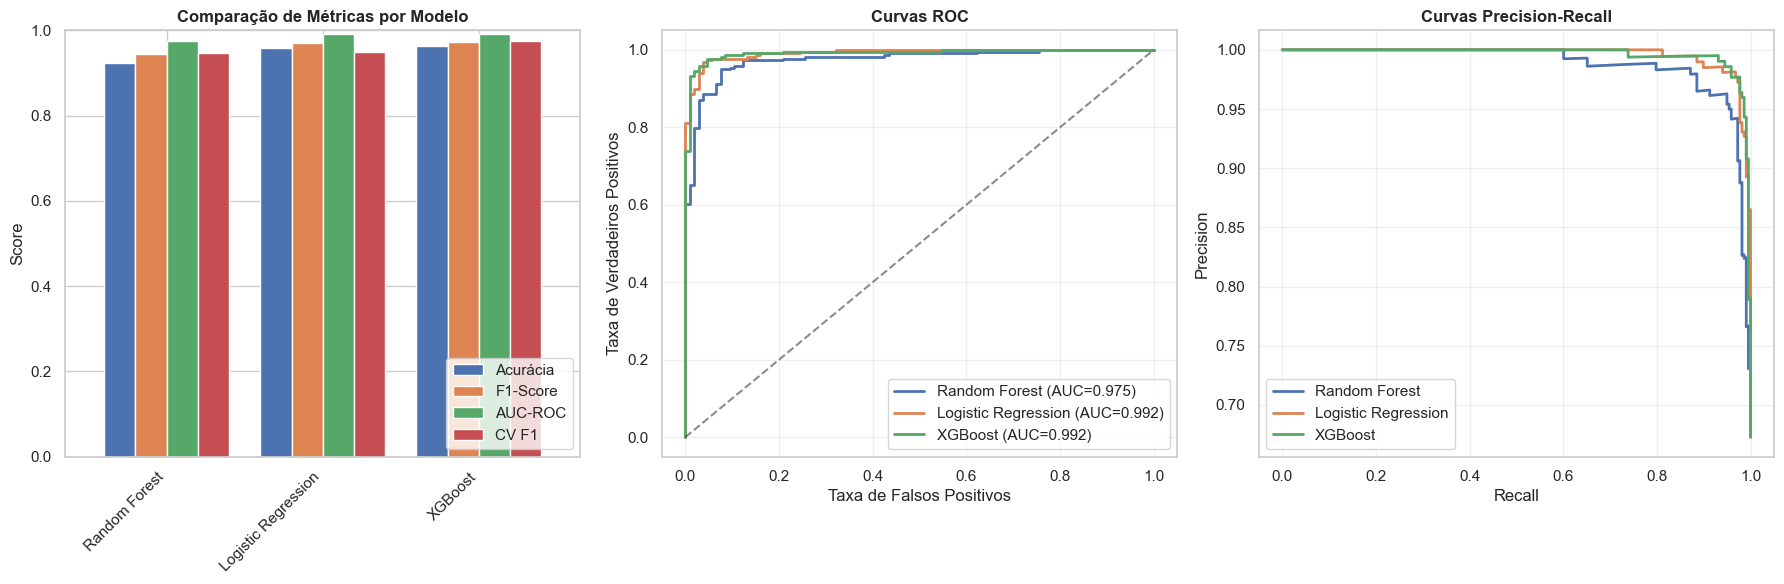


Resumo dos Modelos:
                     Acurácia  F1-Score  AUC-ROC  CV F1
Random Forest           0.923     0.944    0.975  0.948
Logistic Regression     0.960     0.970    0.992  0.949
XGBoost                 0.963     0.973    0.992  0.976


In [8]:
# Comparação dos modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Métricas comparativas
metrics_df = pd.DataFrame({
    name: {'Acurácia': r['accuracy'], 'F1-Score': r['f1'], 'AUC-ROC': r['auc'], 'CV F1': r['cv_f1']}
    for name, r in results.items()
}).T

metrics_df.plot(kind='bar', ax=axes[0], edgecolor='white', width=0.8)
axes[0].set_title('Comparação de Métricas por Modelo', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)

# Gráfico 2: Curvas ROC
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('Curvas ROC', fontweight='bold')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Precision-Recall Curves
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[2].plot(rec, prec, label=name, linewidth=2)
axes[2].set_title('Curvas Precision-Recall', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/25_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResumo dos Modelos:")
print(metrics_df.round(3))

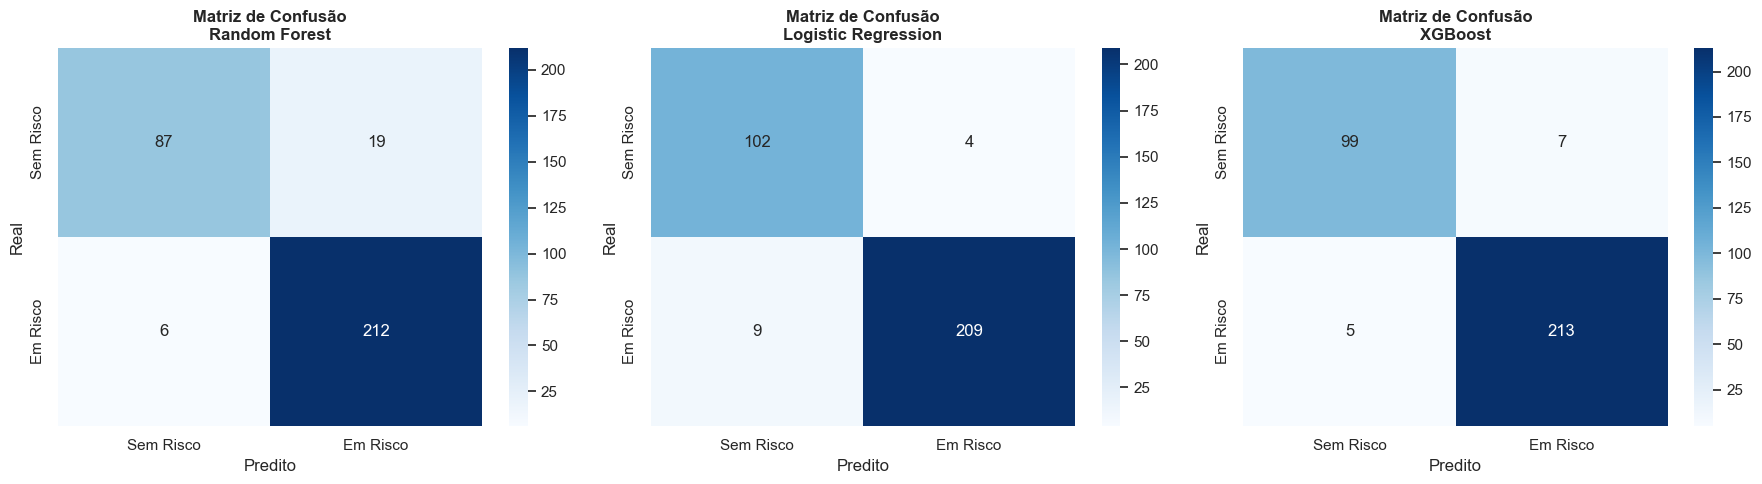

In [9]:
# Matrizes de Confusão
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 5))
if len(results) == 1:
    axes = [axes]

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Sem Risco', 'Em Risco'],
                yticklabels=['Sem Risco', 'Em Risco'])
    axes[i].set_title(f'Matriz de Confusão\n{name}', fontweight='bold')
    axes[i].set_xlabel('Predito')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.savefig('../outputs/26_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()


Melhor modelo: XGBoost
  AUC-ROC: 0.992
  F1-Score: 0.973
  Acurácia: 0.963


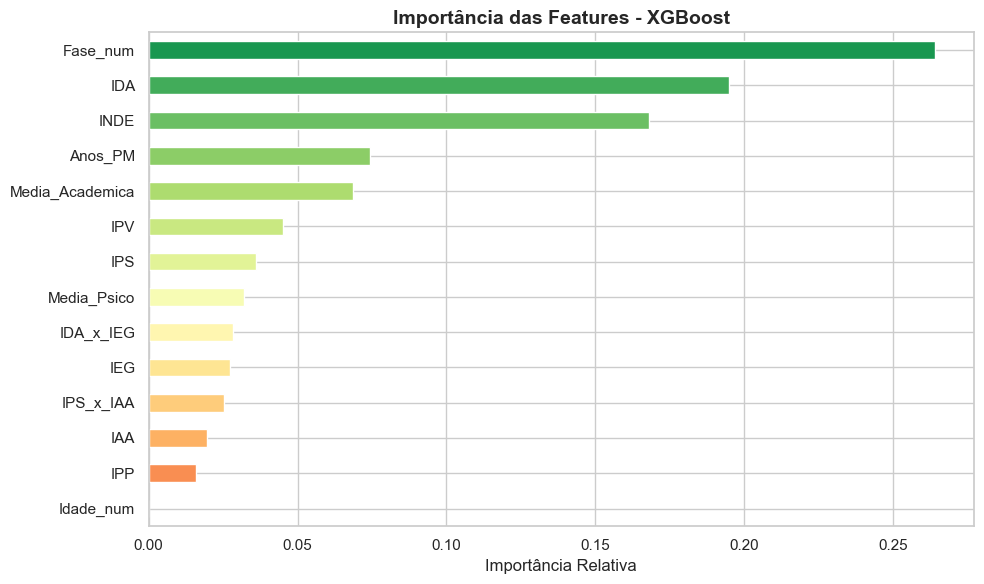

In [10]:
# Selecionar melhor modelo (pelo AUC-ROC)
best_name = max(results, key=lambda x: results[x]['auc'])
best_result = results[best_name]
best_model = best_result['model']
print(f"\nMelhor modelo: {best_name}")
print(f"  AUC-ROC: {best_result['auc']:.3f}")
print(f"  F1-Score: {best_result['f1']:.3f}")
print(f"  Acurácia: {best_result['accuracy']:.3f}")

# Feature Importance do melhor modelo
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=available_features).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(importances)*0.4)))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
    importances.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Importância das Features - {best_name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Importância Relativa')
    plt.tight_layout()
    plt.savefig('../outputs/27_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=available_features).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(coefs)*0.4)))
    coefs.plot(kind='barh', ax=ax, color=['#e74c3c' if v < 0 else '#2ecc71' for v in coefs])
    ax.set_title(f'Coeficientes - {best_name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Coeficiente')
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('../outputs/27_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Salvamento do Modelo

Salvando o melhor modelo treinado e os artefatos necessários para deploy na aplicação Streamlit.

In [11]:
# Salvar modelo, scaler e metadata
os.makedirs('../models', exist_ok=True)

# Retreinar o melhor modelo com todos os dados para deploy
if 'Logistic' in best_name:
    X_all_scaled = scaler.fit_transform(X)
    best_model.fit(X_all_scaled, y)
else:
    best_model.fit(X.values, y)

# Salvar artefatos
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(available_features, '../models/feature_names.pkl')

# Salvar metadados
metadata = {
    'model_name': best_name,
    'features': available_features,
    'metrics': {
        'auc': float(best_result['auc']),
        'f1': float(best_result['f1']),
        'accuracy': float(best_result['accuracy'])
    },
    'target_description': 'em_risco: 1 = aluno em risco de defasagem, 0 = sem risco',
    'criteria': [
        'IAN <= 5.0 (defasagem moderada ou severa)',
        'Defasagem < 0',
        'Pedra = Quartzo'
    ]
}

import json
with open('../models/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Artefatos salvos em ../models/:")
for f in os.listdir('../models'):
    size = os.path.getsize(os.path.join('../models', f))
    print(f"  {f}: {size/1024:.1f} KB")

print(f"\nModelo preditivo concluído com sucesso!")
print(f"Modelo: {best_name}")
print(f"Features: {available_features}")

Artefatos salvos em ../models/:
  best_model.pkl: 457.2 KB
  feature_names.pkl: 0.1 KB
  model_metadata.json: 0.6 KB
  scaler.pkl: 1.3 KB

Modelo preditivo concluído com sucesso!
Modelo: XGBoost
Features: ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE', 'Fase_num', 'Idade_num', 'Anos_PM', 'IDA_x_IEG', 'IPS_x_IAA', 'Media_Academica', 'Media_Psico']


## 7. Conclusão

O modelo preditivo desenvolvido permite identificar alunos em risco de defasagem com base nos indicadores educacionais da Passos Mágicos.

### Principais Resultados:
- O modelo utiliza os indicadores PEDE como features
- A variável alvo combina múltiplos critérios de risco
- A avaliação mostra capacidade de generalização com validação cruzada

### Próximos Passos:
- Deploy do modelo via aplicação Streamlit
- Monitoramento contínuo da performance do modelo
- Atualização periódica com novos dados PEDE